# HW4P1: Language Modelling

Welcome to the final part 1 hw of this course. This is the only part 1 in which you have PyTorch training (Yay). You will be working on training language models and evaluating them on the task of prediction and generation.<br>
Note: A major change which we have made this semester is that we have made the model which you will be coding in this HW very similar to the Speller module from HW4P2. 

# Get modules and datasets

In [99]:
pip install torchsummaryX


Note: you may need to restart the kernel to use updated packages.


# Imports

In [100]:
import sys
from pathlib import Path

HANDOUT_DIR = Path("/home/admin/CMU-11-785-s26/reference/11785HW/HW4/HW4P1")
if not (HANDOUT_DIR / "hw4" / "tests.py").is_file():
    raise FileNotFoundError(f"Cannot find HW4P1 handout at {HANDOUT_DIR}")
if str(HANDOUT_DIR) not in sys.path:
    sys.path.insert(0, str(HANDOUT_DIR))
DATA_DIR = HANDOUT_DIR / "dataset"
FIXTURES_DIR = HANDOUT_DIR / "fixtures"
EXPERIMENTS_DIR = HANDOUT_DIR / "hw4" / "experiments"

In [101]:
sys.path[-1]

'/home/admin/miniforge3/envs/cmu-11785/lib/python3.13/site-packages'

In [102]:
%matplotlib inline

import torch

import os

import time 
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
import torchsummaryX

# Importing necessary modules from hw4
from hw4.tests import test_prediction, test_generation

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device: ", DEVICE)

%cd .


Device:  cuda
/home/admin/CMU-11-785-s26/reference/11785HW/HW4/HW4P1/hw4


# Load datasets

In [103]:
# Loading the vocabulary. Try printing and see
VOCAB       = np.load(DATA_DIR / "vocab.npy") 

# The public dataset copy contains only normal words, so append the
# two sequence-boundary symbols in memory when they are absent.
if "<sos>" not in VOCAB:
    VOCAB = np.concatenate((VOCAB, np.array(["<sos>", "<eos>"])))
SOS_TOKEN   = np.where(VOCAB == '<sos>')[0][0]
EOS_TOKEN   = np.where(VOCAB == '<eos>')[0][0]
NUM_WORDS   = len(VOCAB) - 2 # Actual number of words in vocabulary

print("Vocab length: ", len(VOCAB))
print(VOCAB)


Vocab length:  33280
['!' '"' '#' ... '～' '<sos>' '<eos>']


In [104]:
VOCAB[1417]


np.str_('<eol>')

In [105]:
SOS_TOKEN


np.int64(33278)

In [106]:
EOS_TOKEN


np.int64(33279)

In [107]:
VOCAB[19]


np.str_("'Italia")

In [108]:
SOS_TOKEN


np.int64(33278)

In [109]:
# Loading the training dataset. Refer to writeup section 2.
dataset = np.load(DATA_DIR / "wiki.train.npy", allow_pickle=True)

# TODO: Add <sos> and <eos> to every article in the dataset.
# Keep the result as a one-dimensional object array (one token array per article).
articles = np.empty(len(dataset), dtype=object)
for i, ariticle in enumerate(dataset):
    articles[i] = np.concatenate(
        (
            np.array([SOS_TOKEN], dtype=ariticle.dtype),
            ariticle,
            np.array([EOS_TOKEN], dtype=ariticle.dtype),
            )
        )

In [110]:
dataset = articles

In [111]:
# Prepare validation articles using the same boundary-token convention.
valid_dataset = np.load(DATA_DIR / "wiki.valid.npy", allow_pickle=True)
valid_articles = np.empty(len(valid_dataset), dtype=object)

for i, article in enumerate(valid_dataset):
    valid_articles[i] = np.concatenate(
        (
            np.array([SOS_TOKEN], dtype=article.dtype),
            article,
            np.array([EOS_TOKEN], dtype=article.dtype),
        )
    )

valid_dataset = valid_articles

In [112]:
# Loading the fixtures for validation and test - prediction
fixtures_pred       = np.load(FIXTURES_DIR / "prediction.npz")        # validation
fixtures_pred_test  = np.load(FIXTURES_DIR / "prediction_test.npz")   # test

print("Validation shapes    : ", fixtures_pred['inp'].shape, fixtures_pred['out'].shape)
print("Test shapes          : ", fixtures_pred_test['inp'].shape)

Validation shapes    :  (128, 20) (128,)
Test shapes          :  (128, 20)


In [113]:
# Loading the fixtures for validation and test - generation
fixtures_gen        = np.load(FIXTURES_DIR / "generation.npy")        # validation
fixtures_gen_test   = np.load(FIXTURES_DIR / "generation_test.npy")   # test

print("Validation Gen Shapes    :", fixtures_gen.shape)
print("Test Gen Shapes          :", fixtures_gen_test.shape)


Validation Gen Shapes    : (32, 20)
Test Gen Shapes          : (128, 30)


In [114]:
# Example Prediction Dev Input and Output
# Optional TODO: You can try printing a few samples from the validation set which has both inputs and outputs
print("Input: ", fixtures_pred['inp'][0])
print("Output: ", fixtures_pred['out'][0])
print('generation ', fixtures_gen[0])


Input:  [26096 26972 25821 14658 29325 32935 21820 25639 16134 31353 29092    79
  6916    76 21415 14658 24911  1424 29456 29325]
Output:  72
generation  [32885 31353 22124 32747 20202 28955    76 16786 25881 31453 32846 32022
 14686 31543 15794    79  9916 25821 31365 32846]


In [115]:
dataset[578].shape[0]

8460

# Custom DataLoader

In [116]:
class DataLoaderForLanguageModeling(torch.utils.data.DataLoader):
    """TODO: create non-overlapping language-model batches."""

    def __init__(self, dataset, batch_size, shuffle=False, drop_last=False,
                 sequence_length=20):
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.drop_last = drop_last
        self.sequence_length = sequence_length

    def __len__(self):
        # TODO: return the number of complete batches after concatenation.
        total_tokens = sum(len(ariticle) for ariticle in self.dataset)
        tokens_per_batch = self.batch_size * self.sequence_length
        return (total_tokens - 1) // tokens_per_batch

    def __iter__(self):
        # TODO:
        # 1. Shuffle articles when requested.
        # 2. Concatenate articles and discard any incomplete tail.
        # 3. Create inputs and one-token-shifted targets.
        # 4. Yield tensors shaped (batch_size, sequence_length).
        articles = self.dataset.copy()
        if self.shuffle:
            np.random.shuffle(articles)
        tokens = np.concatenate(articles)
        tokens_per_batch = self.batch_size * self.sequence_length
        num_batchs = (len(tokens) - 1) // tokens_per_batch
        for batch_idx in range(num_batchs):
            start = batch_idx * tokens_per_batch
            inputs = tokens[start: start+tokens_per_batch]
            targets = tokens[start+1: start+tokens_per_batch+1]
            inputs = torch.tensor(
                inputs.reshape(self.batch_size, self.sequence_length),
                dtype=torch.long,
            )
            targets = torch.tensor(
                targets.reshape(self.batch_size, self.sequence_length),
                dtype=torch.long,
            )
            
            yield inputs, targets

In [117]:
# Some sanity checks

dl = DataLoaderForLanguageModeling(
    dataset     = dataset, 
    batch_size  = 32, 
    shuffle     = True, 
    drop_last   = True
    # Input Extra parameters here if needed
)

inputs, targets = next(iter(dl))
print(inputs.shape, targets.shape)

for x, y in dl:
    print(x.shape, y.shape)
    # shape should be (batch_size, sequence_length)
    print("x: ", [VOCAB[i] for i in x[0, :]])
    print("y: ", [VOCAB[i] for i in y[0, :]])
    break


torch.Size([32, 20]) torch.Size([32, 20])
torch.Size([32, 20]) torch.Size([32, 20])
x:  [np.str_('<sos>'), np.str_('='), np.str_('Domnall'), np.str_('mac'), np.str_('Murchada'), np.str_('='), np.str_('<eol>'), np.str_('Domnall'), np.str_('mac'), np.str_('Murchada'), np.str_('('), np.str_('died'), np.str_('1075'), np.str_(')'), np.str_(','), np.str_('also'), np.str_('known'), np.str_('as'), np.str_('Domnall'), np.str_('mac')]
y:  [np.str_('='), np.str_('Domnall'), np.str_('mac'), np.str_('Murchada'), np.str_('='), np.str_('<eol>'), np.str_('Domnall'), np.str_('mac'), np.str_('Murchada'), np.str_('('), np.str_('died'), np.str_('1075'), np.str_(')'), np.str_(','), np.str_('also'), np.str_('known'), np.str_('as'), np.str_('Domnall'), np.str_('mac'), np.str_('Murchada')]


# LanguageModel

In [118]:
class LanguageModel(torch.nn.Module):
    """TODO: embedding -> stacked LSTMCells -> vocabulary logits."""

    def __init__(self, vocab_size, embed_dim, hid_dim):
        super().__init__()
        # TODO: define embedding, one or more LSTMCells, and output projection.
        self.hidden_dim = hid_dim
        self.token_embedding = torch.nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        self.lstm_cells = torch.nn.ModuleList([
            torch.nn.LSTMCell(embed_dim, hid_dim),
            torch.nn.LSTMCell(hid_dim, hid_dim),
            torch.nn.LSTMCell(hid_dim, hid_dim)
        ])
        self.token_prob = torch.nn.Linear(hid_dim, vocab_size)

    def rnn_step(self, embedding, hidden_states_list):
        # TODO: run one timestep through every LSTMCell.
        next_states = []
        x = embedding
        for layer_idx, lstm_cell in enumerate(self.lstm_cells):
            state = hidden_states_list[layer_idx]
            if state is None:
                hidden = x.new_zeros((x.shape[0], self.hidden_dim))
                cell = x.new_zeros((x.shape[0], self.hidden_dim))
            else:
                hidden, cell = state

            hidden, cell = lstm_cell(x, (hidden, cell))
            next_states.append((hidden, cell))
            x = hidden
        return x, next_states

    def predict(self, x):
        # TODO: return raw logits for the token after each input sequence.
        with torch.inference_mode():
            logits, _ = self.forward(x)
        return logits[:,-1,:]

    def generate(self, x, timesteps):
        # TODO: autoregressively generate ``timesteps`` token IDs.
        device = next(self.parameters()).device
        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.long, device=device)
        else:
            x = x.to(device=device, dtype=torch.long)
        
        generated = []
        with torch.inference_mode():
            logits, hidden_states_list = self.forward(x)
            next_token = torch.argmax(logits[:,-1,:], dim=1)
            generated.append(next_token)
            for _ in range(timesteps - 1):
                logits, hidden_states_list = self.forward(
                  next_token.unsqueeze(1),
                  hidden_states_list,
                )
                next_token = torch.argmax(logits[:, -1, :], dim=1)
                generated.append(next_token)
        
        return torch.stack(generated,dim=1)
        
    def forward(self, x, hidden_states_list=None):
        # TODO: return logits of shape (batch, time, vocab) and hidden states.
        embeddings = self.token_embedding(x)
        if hidden_states_list is None:
            hidden_states_list = [None] * len(self.lstm_cells)
        logits_per_step = []
        for t in range(x.shape[1]):
            embedding_t = embeddings[:,t,:]
            hidden, hidden_states_list = self.rnn_step(embedding_t, hidden_states_list)
            logits_t = self.token_prob(hidden)
            logits_per_step.append(logits_t)
        logits = torch.stack(logits_per_step, dim=1)
        return logits, hidden_states_list

# Trainer Class

In [119]:
class Trainer:
    """Train, validate, evaluate fixtures, and save HW4P1 artifacts."""

    def __init__(self, model, loader, val_loader, optimizer, criterion, scheduler,
                 max_epochs=1, run_id="exp"):
        self.model = model
        self.loader = loader
        self.val_loader = val_loader
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.max_epochs = max_epochs
        self.run_id = run_id
        self.epochs = 0
        self.train_losses = []
        self.val_losses = []
        self.predictions = []
        self.predictions_test = []
        self.generated_logits = []
        self.generated_logits_test = []
        self.generated = []
        self.generated_test = []

    def calculate_loss(self, out, target):
        out = out.reshape(-1, out.shape[-1])
        target = target.reshape(-1)
        return self.criterion(out, target)

    def train(self):
        self.model.train()
        self.model.to(DEVICE)
        total_loss = 0.0
        num_batches = 0

        for inputs, targets in tqdm(self.loader):
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            self.optimizer.zero_grad()
            logits, _ = self.model(inputs)
            loss = self.calculate_loss(logits, targets)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
            num_batches += 1

        if num_batches == 0:
            raise RuntimeError("Training DataLoader yielded no complete batches.")

        mean_loss = total_loss / num_batches
        self.epochs += 1
        self.train_losses.append(mean_loss)
        print(
            f"[TRAIN] Epoch [{self.epochs}/{self.max_epochs}] "
            f"Loss: {mean_loss:.4f} "
            f"Lr: {self.optimizer.param_groups[0]['lr']:.6f}"
        )
        return mean_loss

    def validate(self):
        self.model.eval()
        self.model.to(DEVICE)
        total_loss = 0.0
        num_batches = 0

        with torch.inference_mode():
            for inputs, targets in tqdm(self.val_loader):
                inputs = inputs.to(DEVICE)
                targets = targets.to(DEVICE)
                logits, _ = self.model(inputs)
                loss = self.calculate_loss(logits, targets)
                total_loss += loss.item()
                num_batches += 1

        if num_batches == 0:
            raise RuntimeError("Validation DataLoader yielded no complete batches.")

        mean_loss = total_loss / num_batches
        self.val_losses.append(mean_loss)
        if self.scheduler is not None:
            self.scheduler.step(mean_loss)

        print(f"[VAL] Epoch [{self.epochs}/{self.max_epochs}] Loss: {mean_loss:.4f}")
        return mean_loss

    def test(self):
        """Create the validation and hidden-test artifacts required by Autolab."""
        self.model.eval()
        self.model.to(DEVICE)

        with torch.inference_mode():
            predictions = self.model.predict(
                torch.tensor(fixtures_pred["inp"], dtype=torch.long, device=DEVICE)
            ).cpu().numpy()
            predictions_test = self.model.predict(
                torch.tensor(fixtures_pred_test["inp"], dtype=torch.long, device=DEVICE)
            ).cpu().numpy()
            generated_logits = self.model.generate(
                torch.tensor(fixtures_gen, dtype=torch.long, device=DEVICE), 10
            ).cpu().numpy()
            generated_logits_test = self.model.generate(
                torch.tensor(fixtures_gen_test, dtype=torch.long, device=DEVICE), 10
            ).cpu().numpy()

        nll = test_prediction(predictions, fixtures_pred["out"])
        generated = test_generation(fixtures_gen, generated_logits, VOCAB)
        generated_test = test_generation(fixtures_gen_test, generated_logits_test, VOCAB)

        self.predictions.append(predictions)
        self.predictions_test.append(predictions_test)
        self.generated_logits.append(generated_logits)
        self.generated_logits_test.append(generated_logits_test)
        self.generated.append(generated)
        self.generated_test.append(generated_test)
        print(f"[FIXTURE] Epoch [{self.epochs}/{self.max_epochs}] NLL: {nll:.4f}")
        return nll

    def save(self):
        if not self.predictions:
            raise RuntimeError("Call test() before save().")

        run_dir = EXPERIMENTS_DIR / self.run_id
        run_dir.mkdir(parents=True, exist_ok=True)
        epoch = self.epochs

        torch.save({"state_dict": self.model.state_dict()}, run_dir / f"model-{epoch}.pkl")
        np.save(run_dir / f"predictions-{epoch}.npy", self.predictions[-1])
        np.save(run_dir / f"predictions-test-{epoch}.npy", self.predictions_test[-1])
        np.save(run_dir / f"generated_logits-{epoch}.npy", self.generated_logits[-1])
        np.save(run_dir / f"generated_logits-test-{epoch}.npy", self.generated_logits_test[-1])
        (run_dir / f"generated-{epoch}.txt").write_text(self.generated[-1])
        (run_dir / f"generated-test-{epoch}.txt").write_text(self.generated_test[-1])


# Experiment setup

In [120]:
# TODO: define other hyperparameters here

configs = dict(
    batch_size  = 256,
    num_epochs  = 10, # 10 or 20 epochs should be enough given the model is good
    init_lr     = 0.001 # TODO
)


In [121]:
model       = LanguageModel(vocab_size = len(VOCAB), embed_dim = 256, hid_dim = 256).to(DEVICE)
# TODO: Define the model

loader = DataLoaderForLanguageModeling(
    dataset, batch_size=configs["batch_size"], shuffle=True
)
val_loader = DataLoaderForLanguageModeling(
    valid_dataset, batch_size=configs["batch_size"], shuffle=False
)

criterion   = torch.nn.CrossEntropyLoss() 

optimizer   = torch.optim.Adam(model.parameters(), lr=configs['init_lr'])
# TODO: Define the optimizer. Adam/AdamW usually works good for this HW

# Optional TODO: Use a scheduler if you want
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode= 'min', patience =2)

print(model)
trainable_params = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")


LanguageModel(
  (token_embedding): Embedding(33280, 256)
  (lstm_cells): ModuleList(
    (0-2): 3 x LSTMCell(256, 256)
  )
  (token_prob): Linear(in_features=256, out_features=33280, bias=True)
)
Trainable parameters: 18,651,648


In [122]:
# Dont change this cell

run_id = str(int(time.time()))
EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)
run_dir = EXPERIMENTS_DIR / run_id
run_dir.mkdir()
print(f"Saving models, predictions, and generated words to {run_dir}")

# The object of the Trainer class takes in everything
trainer = Trainer(
    model       = model, 
    loader      = loader, 
    val_loader  = val_loader,

    optimizer   = optimizer,
    criterion   = criterion, 
    scheduler   = scheduler,
    max_epochs  = configs['num_epochs'], 
    run_id      = run_id
)


Saving models, predictions, and generated words to /home/admin/CMU-11-785-s26/reference/11785HW/HW4/HW4P1/hw4/experiments/1786687283


In [123]:
# Run the experiments loop. 
# Each epoch wont take more than 2-3min. If its taking more time, it might be due to (but not limited to) the following:
#   * You might be overlapping batches 
#       Eg. Input: "I had biryani for lunch today" and sequence length = 3,
#           --> "I had biryani", "for lunch today" are ideal examples for inputs
#           --> "I had biryani", "had biryani for", "biryani for lunch", ... is just redundant info :')
#   * Your length calculation in the dataloader might be wrong
# If you haven't had biryani, try it :D 

# %%time
best_nll = 1e30 
for epoch in range(configs['num_epochs']):
    trainer.train()
    trainer.validate()
    nll = trainer.test()
    if nll < best_nll:
        best_nll = nll
        print("Saving model, predictions and generated output for epoch "+str(epoch+1)+" with NLL: "+ str(best_nll))
        trainer.save()


100%|██████████| 405/405 [00:09<00:00, 41.61it/s]


[TRAIN] Epoch [1/10] Loss: 7.4560 Lr: 0.001000
[FIXTURE] Epoch [1/10] NLL: 6.7059
Saving model, predictions and generated output for epoch 1 with NLL: 6.705878


100%|██████████| 405/405 [00:09<00:00, 41.80it/s]


[TRAIN] Epoch [2/10] Loss: 7.2306 Lr: 0.001000
[FIXTURE] Epoch [2/10] NLL: 6.5619
Saving model, predictions and generated output for epoch 2 with NLL: 6.561919


100%|██████████| 405/405 [00:12<00:00, 33.45it/s]


...

[TRAIN] Epoch [8/10] Loss: 5.5619 Lr: 0.001000
[FIXTURE] Epoch [8/10] NLL: 5.0113
Saving model, predictions and generated output for epoch 8 with NLL: 5.011303


100%|██████████| 405/405 [00:09<00:00, 42.22it/s]


[TRAIN] Epoch [9/10] Loss: 5.4540 Lr: 0.001000
[FIXTURE] Epoch [9/10] NLL: 4.9660
Saving model, predictions and generated output for epoch 9 with NLL: 4.965977


100%|██████████| 405/405 [00:11<00:00, 34.06it/s]


[TRAIN] Epoch [10/10] Loss: 5.3601 Lr: 0.001000
[FIXTURE] Epoch [10/10] NLL: 4.9378
Saving model, predictions and generated output for epoch 10 with NLL: 4.937769


ValueError: x and y must have same first dimension, but have shapes (10,) and (0,)

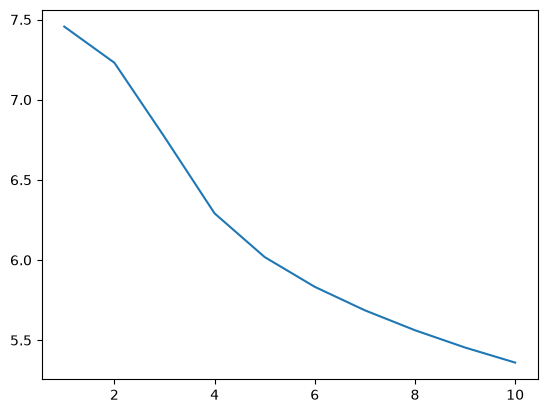

In [124]:
plt.figure()
plt.plot(range(1, len(trainer.train_losses) + 1), trainer.train_losses, label='Training losses')
plt.plot(range(1, len(trainer.val_losses) + 1), trainer.val_losses, label='Validation losses')
plt.xlabel('Epochs')
plt.ylabel('NLL')
plt.legend()
plt.show()


# Create handin

In [ ]:
# TODO: Generate the handin to submit to autolab
!make runid=<ENTER RUN ID> epoch=<ENTER EPOCH NUMBER>
